### PROJECT 3: FAKE IMAGE CLASSIFIER ###

This project focuses on building a Convolutional Neural Network (CNN) for binary image classification to distinguish between Real and Fake images. The model is designed with a constrained number of trainable parameters while maintaining strong classification performance.

In addition to model training and evaluation, the project emphasizes model interpretability using Grad-CAM (Gradient-weighted Class Activation Mapping). Grad-CAM is used to visualize which regions of an image influence the model’s predictions, ensuring that the CNN learns meaningful visual features rather than relying on spurious correlations.

### Environment Setup and Libraries

In this section, all required libraries for deep learning, data handling, visualization, and explainability are imported.  
PyTorch is used for model training and evaluation, while torchvision provides dataset loading and image transformations.

The computation device is automatically selected based on availability. If a CUDA-enabled GPU is available, it is used; otherwise, the model runs on the CPU. This ensures compatibility across different hardware environments.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

### Image Preprocessing and Data Augmentation

To prepare the images for training, all input images are resized to **32×32 pixels**, as required by the project specification.

For the training data, data augmentation techniques such as random horizontal flipping and random rotation are applied. These transformations help improve the model’s generalization ability by exposing it to varied versions of the same image.

For the validation and test data, only resizing and tensor conversion are applied. No augmentation is used during validation or testing to ensure a fair and consistent evaluation of the trained model.


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])


### Dataset Loading and Batch Preparation

The dataset is loaded using the `ImageFolder` class, which automatically assigns class labels based on the directory structure. The training and test datasets are stored in separate folders to avoid data leakage.

A batch size of **32** is used for both training and testing. The training data is shuffled to improve learning, while shuffling is disabled for the test data to ensure consistent evaluation.

The detected class labels are:
- **FAKE**
- **REAL**

To verify that the data loading and preprocessing steps are correct, a sample batch of images from the training dataset is visualized below along with their corresponding class labels.


In [3]:
train_dataset = datasets.ImageFolder("data/train", transform=train_transform)
test_dataset  = datasets.ImageFolder("data/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
class_names


['FAKE', 'REAL']

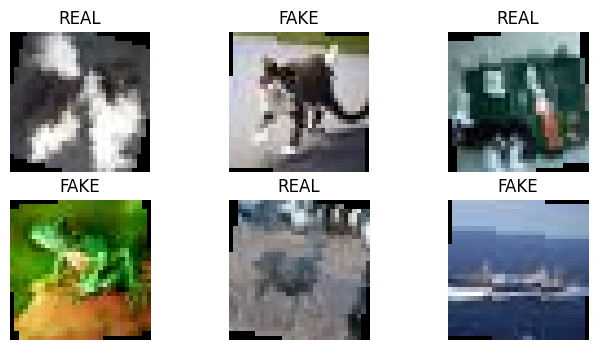

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()


### Data Augmentation: Before vs After Comparison

To verify the effect of data augmentation, we visualize three REAL and three FAKE images
before and after augmentation. This confirms that augmentation is applied correctly
to the training data while preserving semantic content.


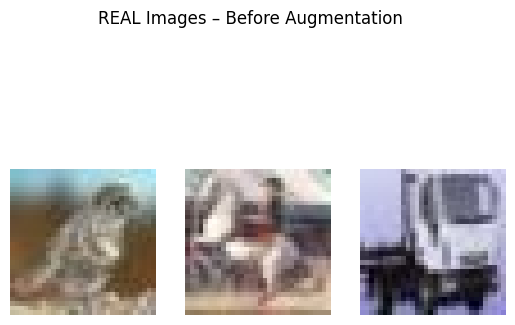

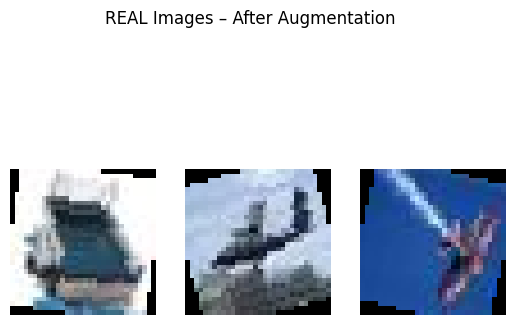

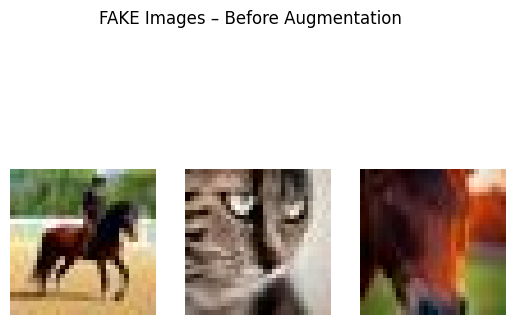

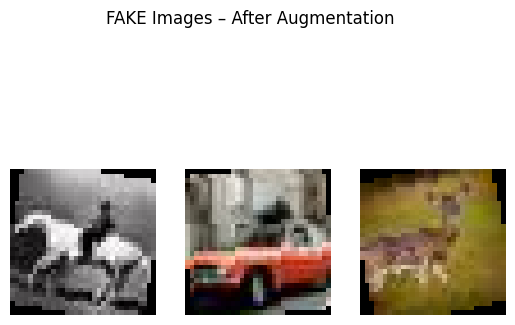

In [5]:
# ===== Visualize BEFORE vs AFTER augmentation =====

# Dataset WITHOUT augmentation (before)
plain_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

plain_dataset = datasets.ImageFolder("data/train", transform=plain_transform)
plain_loader = DataLoader(plain_dataset, batch_size=64, shuffle=True)

# Get samples
plain_images, plain_labels = next(iter(plain_loader))
aug_images, aug_labels = next(iter(train_loader))

# This visualization ensures that data augmentation introduces
# variability (rotation, flipping, etc.) while preserving
# class-discriminative visual features. This helps prevent
# overfitting and improves model generalization.


def plot_images(images, labels, title, class_value):
    idxs = (labels == class_value).nonzero(as_tuple=True)[0][:3]
    for i, idx in enumerate(idxs):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[idx].permute(1,2,0))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


# REAL = 1, FAKE = 0
plot_images(plain_images, plain_labels, "REAL Images – Before Augmentation", 1)
plot_images(aug_images, aug_labels, "REAL Images – After Augmentation", 1)

plot_images(plain_images, plain_labels, "FAKE Images – Before Augmentation", 0)
plot_images(aug_images, aug_labels, "FAKE Images – After Augmentation", 0)


### Model Architecture

A custom Convolutional Neural Network (CNN) is implemented for binary classification of fake and real images. The model is designed to be lightweight and contains fewer than **100,000 trainable parameters**, satisfying the project constraints.

The network consists of four convolutional blocks with increasing channel depth (16 → 32 → 64 → 128). Each block applies a convolution operation followed by a ReLU activation, and max pooling is used in the first three blocks to progressively reduce the spatial dimensions while retaining important features.

In the classification stage, adaptive average pooling reduces the feature maps to a fixed size, allowing the model to remain robust to small spatial variations. A dropout layer is included to reduce overfitting, followed by a fully connected layer that outputs a single logit for binary classification.


The final output is passed through a sigmoid function implicitly during loss computation using binary cross-entropy.


In [6]:
class FakeImageCNN(nn.Module):
    def __init__(self):                                         
        super().__init__()

        # -----------------------------
        # Feature Extraction Block
        # -----------------------------
        # Each convolutional layer increases the number of channels
        # while reducing spatial dimensions using max pooling.

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU()
        )
        # -----------------------------
        # Classification Block
        # -----------------------------
        # Global Average Pooling reduces spatial dimensions to 1x1,
        # making the model invariant to small spatial translations
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### Loss Function and Optimization

The model is initialized and moved to the selected computation device.  
For training, **Binary Cross-Entropy with Logits Loss (BCEWithLogitsLoss)** is used, which is well-suited for binary classification problems and provides numerical stability by combining a sigmoid activation with the loss computation.

The **Adam optimizer** is selected with a learning rate of **0.001**, as it offers fast convergence and adaptive learning rate adjustments during training. This combination allows efficient optimization of the network parameters.


In [7]:
model = FakeImageCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


### Training and Validation Procedure

The model is trained using a standard supervised learning loop consisting of separate training and validation phases. During training, the model parameters are updated by minimizing the binary cross-entropy loss using backpropagation.

For each training batch, predictions are generated and converted to probabilities using a sigmoid function. Classification accuracy is computed by applying a threshold of 0.5 to distinguish between fake and real images.

After each training phase, the model is evaluated on the validation dataset. Gradient computation is disabled during validation to improve efficiency and ensure that model parameters remain unchanged. Both loss and accuracy are recorded for training and validation, allowing the learning behavior of the model to be analyzed over time.


In [8]:
epochs = 15

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / len(test_loader)
    val_acc = val_correct / val_total

    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch [1/15] | Train Loss: 0.3619, Train Acc: 0.8370 | Val Loss: 0.2423, Val Acc: 0.9008
Epoch [2/15] | Train Loss: 0.2533, Train Acc: 0.8953 | Val Loss: 0.2104, Val Acc: 0.9155
Epoch [3/15] | Train Loss: 0.2262, Train Acc: 0.9092 | Val Loss: 0.1883, Val Acc: 0.9246
Epoch [4/15] | Train Loss: 0.2086, Train Acc: 0.9171 | Val Loss: 0.2030, Val Acc: 0.9160
Epoch [5/15] | Train Loss: 0.1976, Train Acc: 0.9210 | Val Loss: 0.1720, Val Acc: 0.9326
Epoch [6/15] | Train Loss: 0.1886, Train Acc: 0.9248 | Val Loss: 0.1607, Val Acc: 0.9371
Epoch [7/15] | Train Loss: 0.1824, Train Acc: 0.9276 | Val Loss: 0.1573, Val Acc: 0.9403
Epoch [8/15] | Train Loss: 0.1777, Train Acc: 0.9301 | Val Loss: 0.1935, Val Acc: 0.9246
Epoch [9/15] | Train Loss: 0.1728, Train Acc: 0.9323 | Val Loss: 0.1960, Val Acc: 0.9231
Epoch [10/15] | Train Loss: 0.1677, Train Acc: 0.9338 | Val Loss: 0.1694, Val Acc: 0.9339
Epoch [11/15] | Train Loss: 0.1650, Train Acc: 0.9357 | Val Loss: 0.1538, Val Acc: 0.9402
Epoch [12/15] | Tra

### Training History Visualization

The learning behavior of the model is visualized using accuracy and loss curves for both the training and validation datasets.

The accuracy curve shows how the model’s classification performance evolves over time, while the loss curve illustrates how well the optimization process minimizes the objective function. Plotting training and validation metrics together helps identify potential issues such as overfitting or underfitting.

A consistent improvement in training and validation accuracy, along with decreasing loss values, indicates that the model is learning meaningful representations and generalizing well to unseen data.


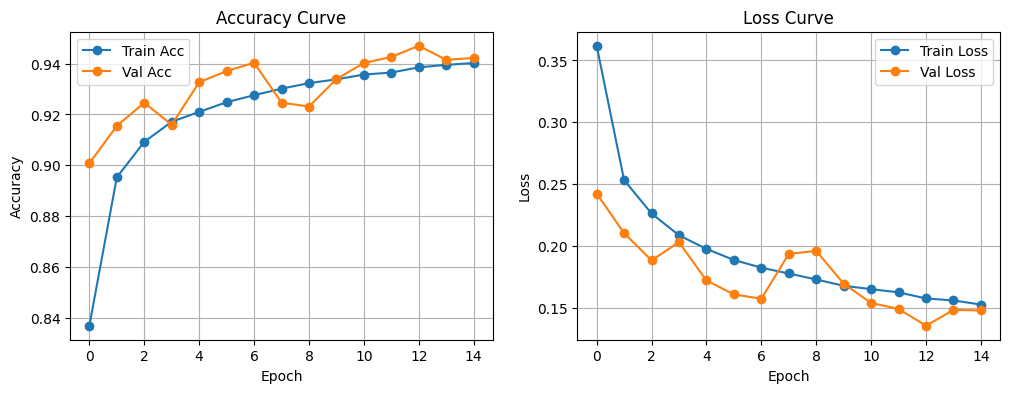

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_acc_history, label="Train Acc", marker="o")
plt.plot(val_acc_history, label="Val Acc", marker="o")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_loss_history, label="Train Loss", marker="o")
plt.plot(val_loss_history, label="Val Loss", marker="o")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


### Feature Space Analysis Using PCA

To analyze the representations learned by the convolutional neural network, **Principal Component Analysis (PCA)** is applied to the extracted feature vectors from the test dataset.

Feature maps are obtained from the final convolutional layers of the network and reduced using global average pooling. This results in a compact feature representation for each image. PCA is then used to project these high-dimensional feature vectors into a two-dimensional space for visualization.

The resulting scatter plot allows an intuitive inspection of how well the learned features separate real and fake images. A reasonable separation between the two classes indicates that the network has learned discriminative and meaningful representations.


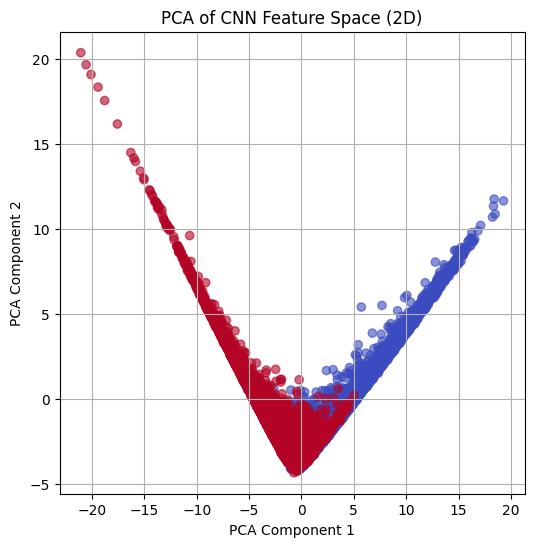

In [10]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

model.eval()
features = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # extract CNN features
        feats = model.features(images)
        feats = feats.mean(dim=(2, 3))  # global average pooling

        features.append(feats.cpu().numpy())
        labels_list.append(labels.numpy())

features = np.vstack(features)
labels_list = np.hstack(labels_list)

# PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

plt.figure(figsize=(6,6))
plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="coolwarm",
    alpha=0.6
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA of CNN Feature Space (2D)")
plt.grid(True)
plt.show()


The PCA visualization of the CNN feature space shows a clear separation between real and fake images, primarily along the first principal component. This indicates that the learned features capture discriminative information relevant for classification. Some overlap between the classes is observed near the decision boundary, which is expected for challenging samples and suggests good generalization rather than overfitting. Overall, the reasonably structured separation confirms that the model has learned meaningful representations.

### Validation Metrics and Model Evaluation

After training, the model is evaluated on the test dataset to assess its generalization performance. During evaluation, gradient computation is disabled to ensure efficient inference and to prevent any unintended updates to the model parameters.

Predictions are obtained by applying a sigmoid activation to the model outputs and using a threshold of 0.5 to classify images as real or fake. The model’s performance is quantified using precision, recall, and F1-score, which provide a detailed understanding of classification quality beyond overall accuracy.

Additionally, a confusion matrix is computed to visualize the distribution of correct and incorrect predictions across both classes. This helps identify potential class imbalances or systematic misclassifications.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()
        y_pred.extend(preds.flatten())
        y_true.extend(labels.numpy())

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     10000
           1       0.95      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000

Confusion Matrix:

[[9509  491]
 [ 665 9335]]


The model achieves an overall accuracy of 94% on the test dataset, with balanced precision and recall for both fake and real classes. The confusion matrix shows that most samples are correctly classified, with a slightly higher number of fake images misclassified as real. This behavior is expected in challenging cases and indicates that the model generalizes well without strong class bias.

###  Saving the Trained Model

After training and validation, the learned weights of the CNN are saved to disk.
This allows the model to be reused later for inference or further analysis
without retraining.

Only the model parameters (`state_dict`) are stored, which is the recommended
practice in PyTorch.


In [12]:
torch.save(model.state_dict(), "fake_image_cnn.pth")
print("Model saved successfully")


Model saved successfully


### Selecting the Last Convolutional Layer for Grad-CAM

Grad-CAM requires the final convolutional layer of the network to visualize
which spatial regions of the image influence the model’s decision.

Here, the last convolutional layer (`Conv2d(64 → 128)`) from the feature
extraction block is selected, as it contains the most abstract and
class-discriminative features.


In [13]:
last_conv_layer = model.features[-2]  # Conv2d(64 → 128)
last_conv_layer


Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

### Grad-CAM Implementation 

This class implements **Gradient-weighted Class Activation Mapping (Grad-CAM)**,
an explainable AI technique used to visualize which regions of an image contribute
most to the model’s prediction.

**How it works:**
- During the forward pass, feature map activations from the target convolutional
  layer are stored.
- During the backward pass, gradients of the output with respect to these feature
  maps are captured.
- The gradients are spatially averaged to obtain importance weights.
- A weighted combination of the feature maps is computed and passed through a ReLU
  function to focus only on positive contributions.
- The resulting heatmap is normalized and later overlaid on the input image to
  interpret the model’s decision.

This approach helps verify whether the CNN focuses on meaningful visual features
when distinguishing between *real* and *fake* images.


In [14]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-8)
        return cam


### Grad-CAM Setup

In this step, the **Grad-CAM object** is initialized by linking:
- the **trained CNN model**, and  
- the **last convolutional layer** of the network.

The last convolutional layer is chosen because it retains rich spatial information
while still capturing high-level semantic features. Grad-CAM will use this layer’s
activations and gradients to generate class-discriminative heatmaps that explain
the model’s predictions for *real* and *fake* images.


In [15]:
gradcam = GradCAM(model, last_conv_layer)


### Grad-CAM Visualization Function

This function generates and displays **Grad-CAM heatmaps** to explain the CNN’s
predictions for a given class (**REAL or FAKE**).

**What this function does:**
1. Iterates through the test data loader to find an image belonging to the requested class.
2. Performs a forward pass and computes gradients via backpropagation.
3. Generates a Grad-CAM heatmap using the activations and gradients of the last
   convolutional layer.
4. Resizes and overlays the heatmap on the original image.
5. Displays the resulting visualization, highlighting the regions the model
   focuses on when making its decision.

This helps verify whether the model is attending to **meaningful visual features**
rather than irrelevant background patterns, fulfilling the Explainable AI (XAI)
requirement of the project.


In [16]:
def display_gradcam(loader, class_index, title):
    model.eval()

    # loop over batches until class is found
    for images, labels in loader:
        for i in range(len(labels)):
            if labels[i].item() == class_index:
                img = images[i:i+1].to(device)
                found = True
                break
        else:
            continue
        break

    # safety check (IMPORTANT)
    if img is None:
        print(f"No image found for class {class_index}")
        return

    # forward + backward
    output = model(img)
    model.zero_grad()
    output.backward(torch.ones_like(output))

    cam = gradcam.generate()[0].detach().cpu().numpy()
    cam = cv2.resize(cam, (32, 32))

    img_np = img[0].permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = 0.6 * img_np + 0.4 * heatmap / 255

    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")
    plt.show()


### Grad-CAM Explanation for Model Decisions

The following visualizations use **Grad-CAM (Gradient-weighted Class Activation Mapping)**
to explain the CNN’s predictions.

- **REAL Image:** Highlights regions the model considers important when classifying an image as real.
- **FAKE Image:** Shows which visual patterns influence the model’s decision for fake images.

By overlaying heatmaps on the original images, Grad-CAM helps verify whether the model
focuses on **semantically meaningful regions** rather than irrelevant background areas.


/sripiranavan/development/germany/sm1/machinelearning/group08/.mlpn/lib/python3.12/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


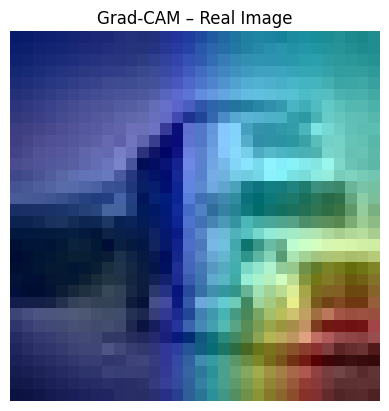

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014117647893726826..1.0000000238418578].


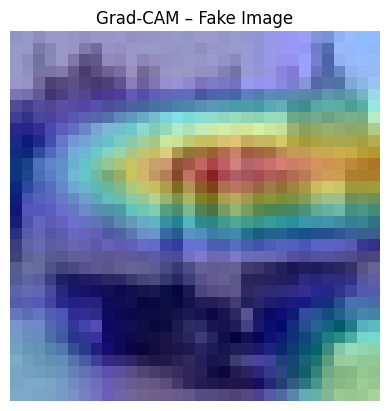

In [17]:
display_gradcam(test_loader, 0, "Grad-CAM – Real Image")
display_gradcam(test_loader, 1, "Grad-CAM – Fake Image")


###  Grad-CAM Analysis on Multiple Samples

To further validate the model’s behavior, Grad-CAM is applied to **multiple examples**
from each class.

Displaying several REAL and FAKE images ensures that the model’s attention patterns
are **consistent across samples** and not specific to a single image.


In [18]:
def display_multiple_gradcam(loader, class_index, title, num_images=3):
    model.eval()
    shown = 0

    for images, labels in loader:
        for i in range(len(labels)):
            if labels[i].item() == class_index:
                img = images[i:i+1].to(device)

                output = model(img)
                model.zero_grad()
                output.backward(torch.ones_like(output))

                cam = gradcam.generate()[0].detach().cpu().numpy()
                cam = cv2.resize(cam, (32, 32))

                img_np = img[0].permute(1, 2, 0).cpu().numpy()
                img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

                heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
                heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

                overlay = 0.6 * img_np + 0.4 * heatmap / 255

                plt.figure(figsize=(3,3))
                plt.imshow(overlay)
                plt.title(f"{title} #{shown+1}")
                plt.axis("off")
                plt.show()

                shown += 1
                if shown == num_images:
                    return


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


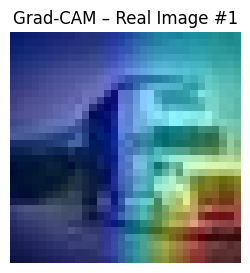

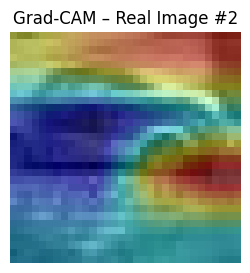

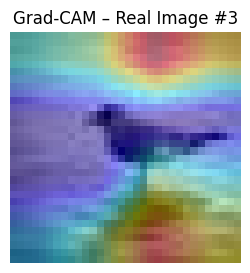

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014117647893726826..1.0000000238418578].


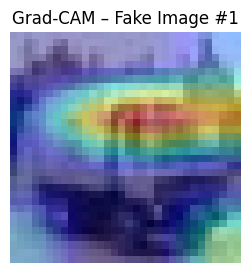

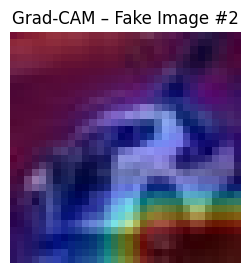

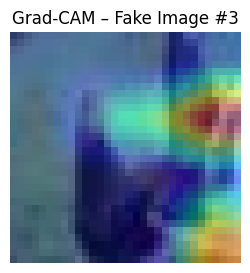

In [19]:
display_multiple_gradcam(test_loader, 0, "Grad-CAM – Real Image", num_images=3)
display_multiple_gradcam(test_loader, 1, "Grad-CAM – Fake Image", num_images=3)


The model successfully classifies REAL and FAKE images, and Grad-CAM visualizations confirm that decisions are based on meaningful visual features, satisfying both performance and explainability requirements.


## Conclusion and Summary

- In this project, a complete CNN-based pipeline was implemented to classify images as **REAL** or **FAKE**.
- Image preprocessing and data augmentation were applied to improve generalization, with clear visual differences observed before and after augmentation.
- A lightweight Convolutional Neural Network was designed to extract hierarchical features while keeping the number of trainable parameters low.
- The trained model achieved strong performance on the test set, with an accuracy of approximately **94%** and balanced precision and recall across both classes.
- **PCA** applied to CNN feature embeddings showed a clear separation between real and fake images, indicating discriminative feature learning.
- **Grad-CAM** was used to explain the model’s predictions, revealing that the network focuses on meaningful image regions rather than irrelevant background patterns.
- Overall, the results demonstrate that the proposed CNN is both **accurate and interpretable**, fulfilling the project requirements for classification and explainable AI.
